#### Import Library

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor as vif
from statsmodels.tools.tools import add_constant

#### Load Data

In [ ]:
from google.colab import files
files.upload()  # Pilih file 'kaggle.json'

{}

Pilih cancel upload

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json
!kaggle datasets download -d nikhil7280/weather-type-classification
!unzip weather-type-classification.zip

mv: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/nikhil7280/weather-type-classification
License(s): other
  0% 0.00/186k [00:00<?, ?B/s]
100% 186k/186k [00:00<00:00, 27.5MB/s]
Archive:  weather-type-classification.zip
  inflating: weather_classification_data.csv  


In [ ]:
data = pd.read_csv('weather_classification_data.csv')
data.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,partly cloudy,1010.82,2,Winter,3.5,inland,Rainy
1,39.0,96,8.5,71.0,partly cloudy,1011.43,7,Spring,10.0,inland,Cloudy
2,30.0,64,7.0,16.0,clear,1018.72,5,Spring,5.5,mountain,Sunny
3,38.0,83,1.5,82.0,clear,1026.25,7,Spring,1.0,coastal,Sunny
4,27.0,74,17.0,66.0,overcast,990.67,1,Winter,2.5,mountain,Rainy


## Exploratory Data Analysis

In [ ]:
# Jumlah baris dan jumlah kolom
data.shape

(13200, 11)

In [ ]:
data.columns

Index(['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)',
       'Cloud Cover', 'Atmospheric Pressure', 'UV Index', 'Season',
       'Visibility (km)', 'Location', 'Weather Type'],
      dtype='object')

In [ ]:
data.dtypes

,0
Temperature,float64
Humidity,int64
Wind Speed,float64
Precipitation (%),float64
Cloud Cover,object
Atmospheric Pressure,float64
UV Index,int64
Season,object
Visibility (km),float64
Location,object


Data Types tiap atribut

#### Checking Duplicate Records

In [ ]:
data[data.duplicated()]

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type


#### Checking Null/Missing Values

In [ ]:
data.isnull().sum()

,0
Temperature,0
Humidity,0
Wind Speed,0
Precipitation (%),0
Cloud Cover,0
Atmospheric Pressure,0
UV Index,0
Season,0
Visibility (km),0
Location,0


#### Summary Statistics

In [ ]:
data.describe()

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
count,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000,13200.000000
mean,19.127576,68.710833,9.832197,53.644394,1005.827896,4.005758,5.462917
std,17.386327,20.194248,6.908704,31.946541,37.199589,3.856600,3.371499
min,-25.000000,20.000000,0.000000,0.000000,800.120000,0.000000,0.000000
25%,4.000000,57.000000,5.000000,19.000000,994.800000,1.000000,3.000000
50%,21.000000,70.000000,9.000000,58.000000,1007.650000,3.000000,5.000000
75%,31.000000,84.000000,13.500000,82.000000,1016.772500,7.000000,7.500000
max,109.000000,109.000000,48.500000,109.000000,1199.210000,14.000000,20.000000


In [ ]:
data.describe(include="object")
#unique: ada berapa kategori dalam masing-masing variabel
#top: kategori dengan freq terbanyak

,Cloud Cover,Season,Location,Weather Type
count,13200,13200,13200,13200
unique,4,4,3,4
top,overcast,Winter,inland,Rainy
freq,6090,5610,4816,3300


#### Correlation among the features

In [ ]:
# list kolom numerik
cols = data.select_dtypes(exclude=object).columns.tolist()
print(cols)
# list kolom kategori
category = data.select_dtypes(include=object).columns.tolist()
print(category)

['Temperature', 'Humidity', 'Wind Speed', 'Precipitation (%)', 'Atmospheric Pressure', 'UV Index', 'Visibility (km)']
['Cloud Cover', 'Season', 'Location', 'Weather Type']


In [ ]:
#korelasi untuk data numerik
cor_matrix = data[cols].corr()
cor_matrix

,Temperature,Humidity,Wind Speed,Precipitation (%),Atmospheric Pressure,UV Index,Visibility (km)
Temperature,1.000000,-0.207969,-0.070022,-0.287206,0.209188,0.374773,0.250751
Humidity,-0.207969,1.000000,0.406079,0.638631,-0.120653,-0.342694,-0.479969
Wind Speed,-0.070022,0.406079,1.000000,0.443770,-0.077757,-0.068147,-0.311828
Precipitation (%),-0.287206,0.638631,0.443770,1.000000,-0.177444,-0.291601,-0.457444
Atmospheric Pressure,0.209188,-0.120653,-0.077757,-0.177444,1.000000,0.154128,0.120182
UV Index,0.374773,-0.342694,-0.068147,-0.291601,0.154128,1.000000,0.362922
Visibility (km),0.250751,-0.479969,-0.311828,-0.457444,0.120182,0.362922,1.000000


#### Correlation Heat Map

<Axes: >

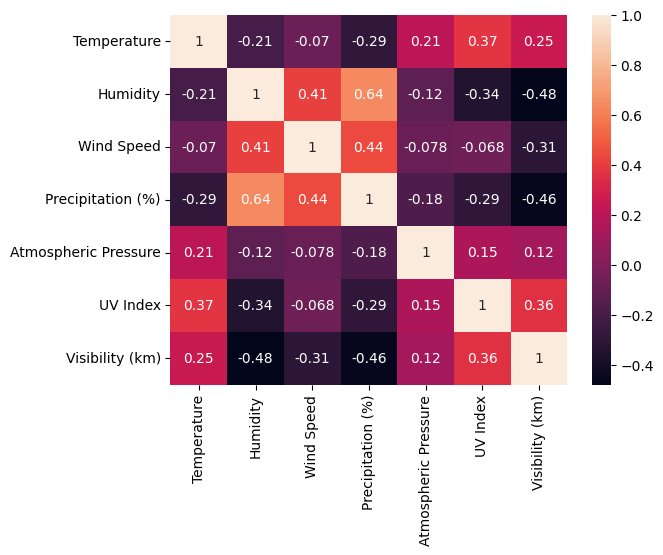

In [ ]:
sns.heatmap(cor_matrix,annot=True)
#annot=True: untuk memberi angka pada kotak

In [ ]:

x_vif = add_constant(data[cols])
x_vif
vif_df = [vif(x_vif.values, i) for i in range(x_vif.shape[1])]
vif_df

vif_df = pd.DataFrame()
vif_df["Features"] = x_vif.columns
vif_df["VIF"] = [vif(x_vif.values, i) for i in range(x_vif.shape[1])]
vif_df[1:]

,Features,VIF
1,Temperature,1.247460
2,Humidity,1.925919
3,Wind Speed,1.325992
4,Precipitation (%),1.969443
5,Atmospheric Pressure,1.066599
6,UV Index,1.346275
7,Visibility (km),1.471022


Tidak ada fitur yang memiliki VIF < 10 menandakan tidak ada multikolenieritas yang dapat mempengaruhi interpretasi dan mempengaruhi kinerja model.

#### Graphical Representations

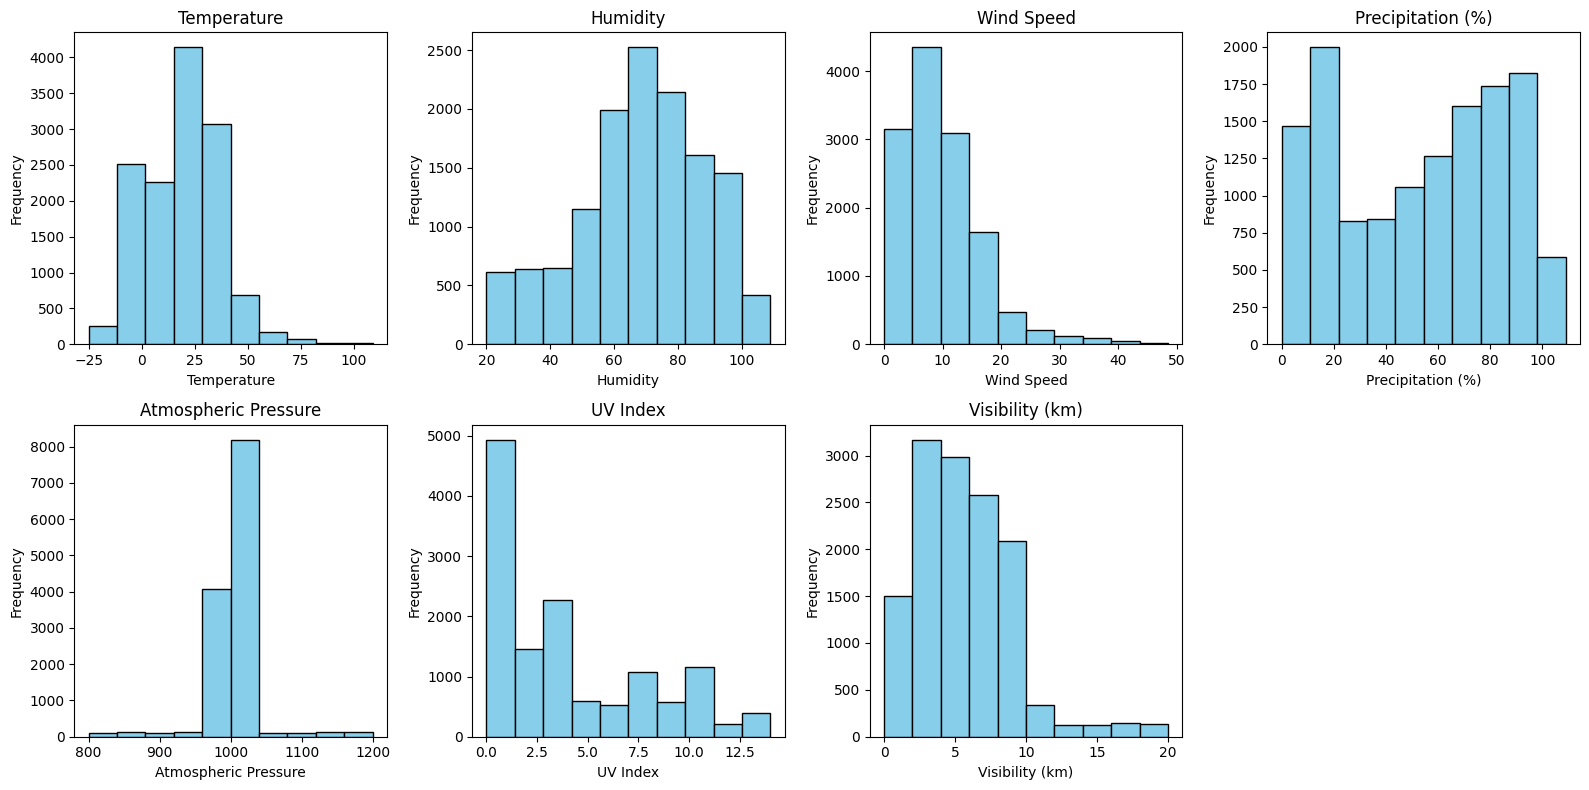

In [ ]:
# Buat figure dengan grid 2x4
fig, axes = plt.subplots(2, 4, figsize=(16, 8))  # 2 baris, 4 kolom, ukuran 16x8 inci
axes = axes.flatten()  # Ubah grid ke array 1 dimensi untuk iterasi

# Loop untuk membuat histogram untuk setiap kolom
for i, col in enumerate(cols):
    if col in data.columns:  # Periksa apakah kolom ada di dataframe
        data[col].plot(kind='hist', ax=axes[i], title=col, color='skyblue', edgecolor='black')
        axes[i].set_xlabel(col)
    else:
        axes[i].axis('off')  # Jika kolom tidak ada, matikan plot

# Sembunyikan subplot yang tidak terpakai jika cols < 8
for i in range(len(cols), len(axes)):
    axes[i].axis('off')

# Tambahkan padding untuk mencegah tumpang tindih
plt.tight_layout()
plt.show()

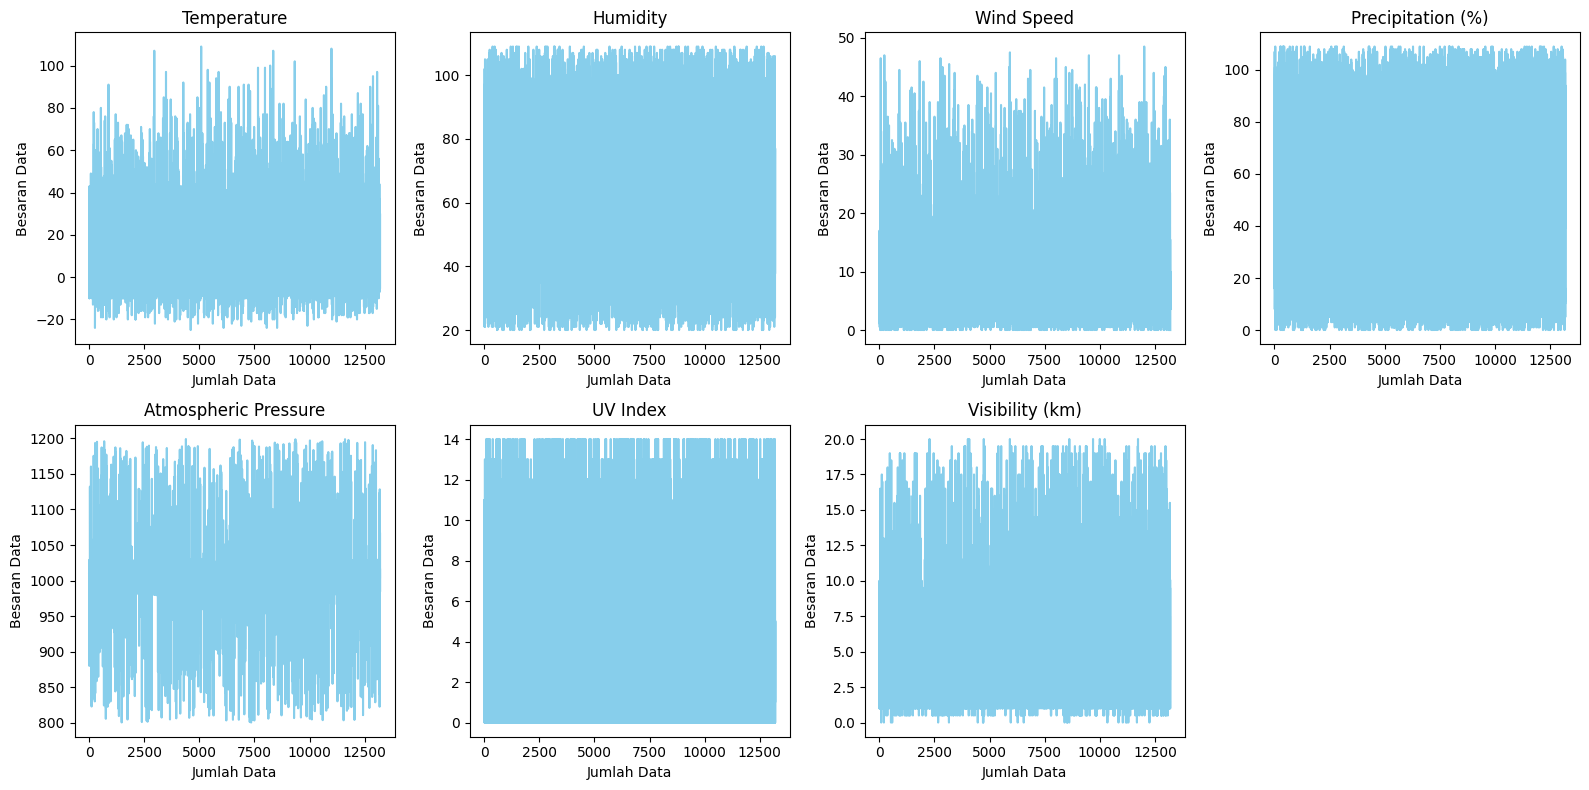

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(16, 8))  # 2 baris, 4 kolom, ukuran 16x8 inci
axes = axes.flatten()  # Ubah grid ke array 1 dimensi untuk iterasi

# Loop untuk membuat line chart untuk setiap kolom
for i, col in enumerate(cols):
    if col in data.columns:  # Periksa apakah kolom ada di dataframe
        axes[i].plot(range(len(data[col])), data[col], color='skyblue')
        axes[i].set_title(col)
        axes[i].set_xlabel('Jumlah Data')  # Label sumbu x
        axes[i].set_ylabel('Besaran Data')  # Label sumbu y
    else:
        axes[i].axis('off')  # Jika kolom tidak ada, matikan plot

# Sembunyikan subplot yang tidak terpakai jika cols < 8
for i in range(len(cols), len(axes)):
    axes[i].axis('off')

# Tambahkan padding untuk mencegah tumpang tindih
plt.tight_layout()
plt.show()

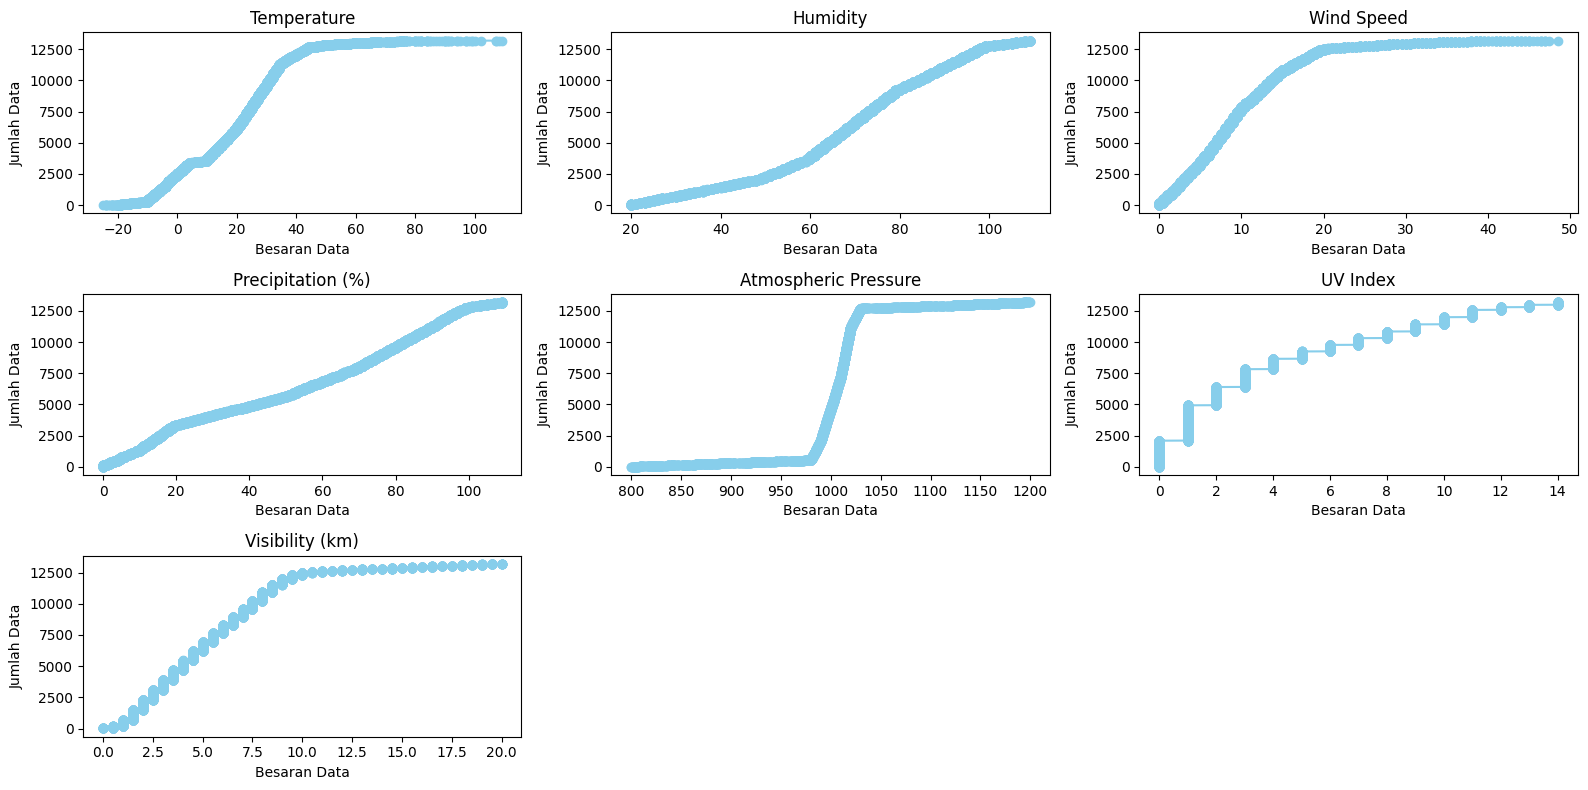

In [ ]:
# Buat figure dengan grid 2x4
fig, axes = plt.subplots(3, 3, figsize=(16, 8))  # 2 baris, 4 kolom, ukuran 16x8 inci
axes = axes.flatten()  # Ubah grid ke array 1 dimensi untuk iterasi

# Loop untuk membuat line chart untuk setiap kolom
for i, col in enumerate(cols):
    if col in data.columns:  # Periksa apakah kolom ada di dataframe
        sorted_data = data[col].sort_values().reset_index(drop=True)  # Urutkan data
        cumulative_count = range(1, len(sorted_data) + 1)  # Hitung jumlah data kumulatif
        axes[i].plot(sorted_data, cumulative_count, color='skyblue', marker='o')
        axes[i].set_title(col)
        axes[i].set_xlabel('Besaran Data')  # Label sumbu x
        axes[i].set_ylabel('Jumlah Data')  # Label sumbu y
    else:
        axes[i].axis('off')  # Jika kolom tidak ada, matikan plot

# Sembunyikan subplot yang tidak terpakai jika cols < 8
for i in range(len(cols), len(axes)):
    axes[i].axis('off')

# Tambahkan padding untuk mencegah tumpang tindih
plt.tight_layout()
plt.show()


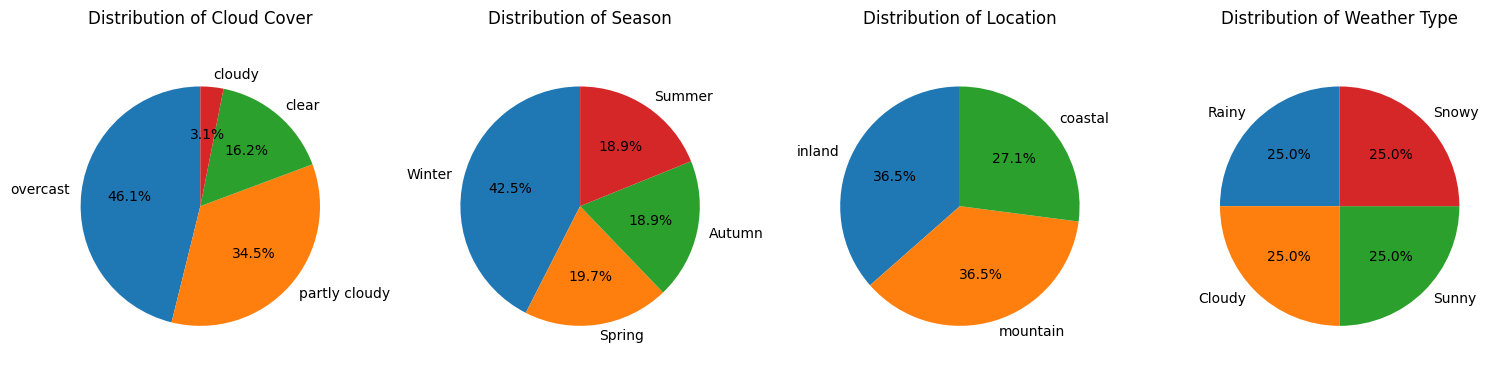

In [ ]:
counts = [data[col].value_counts() for col in category]

fig, axes = plt.subplots(1, len(category), figsize=(15, 4))

for i in range(len(category)):
  axes[i].pie(counts[i], labels=counts[i].index, autopct='%1.1f%%', startangle=90)
  axes[i].set_title("Distribution of " + category[i])
  axes[i].axis('equal')

plt.tight_layout()
plt.show()

In [ ]:
for i, count in enumerate(counts):
    print(count)
    print("-" * 50)

Cloud Cover
overcast         6090
partly cloudy    4560
clear            2139
cloudy            411
Name: count, dtype: int64
--------------------------------------------------
Season
Winter    5610
Spring    2598
Autumn    2500
Summer    2492
Name: count, dtype: int64
--------------------------------------------------
Location
inland      4816
mountain    4813
coastal     3571
Name: count, dtype: int64
--------------------------------------------------
Weather Type
Rainy     3300
Cloudy    3300
Sunny     3300
Snowy     3300
Name: count, dtype: int64
--------------------------------------------------


## Label Encoding

In [ ]:
# We have to do label encoding because the Weather_Type column is the categorical one so we have to
# convert that categories into a numbers
# converting target variable into the numeric

In [ ]:
import sklearn
from sklearn.preprocessing import LabelEncoder

In [ ]:
label_encoder = LabelEncoder()

In [ ]:
for col in category:
    if col != "Weather Type":
      data[col] = label_encoder.fit_transform(data[col])

In [ ]:
data.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location,Weather Type
0,14.0,73,9.5,82.0,3,1010.82,2,3,3.5,1,Rainy
1,39.0,96,8.5,71.0,3,1011.43,7,1,10.0,1,Cloudy
2,30.0,64,7.0,16.0,0,1018.72,5,1,5.5,2,Sunny
3,38.0,83,1.5,82.0,0,1026.25,7,1,1.0,0,Sunny
4,27.0,74,17.0,66.0,2,990.67,1,3,2.5,2,Rainy


## Processing Data

#### Convert this into a dependent and independent

In [ ]:
# Semua adalah x (independent variables) kecuali Weather_Type adalah y (dependent variables)

In [ ]:
# Independent variable: melakukan drop pada dependent variable
x = data.drop(['Weather Type'],axis=1)
# Target variable
y = data['Weather Type']

#### Normalisasi

In [ ]:
# Untuk membuat numerical data pada dataset memiliki rentang nilai (scale) yang sama.
# Tidak ada lagi satu variabel data yang mendominasi variabel data lainnya

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
std_scaler = StandardScaler()

In [ ]:
x_std = std_scaler.fit_transform(x)
x_std

array([[-0.29493119,  0.21240351, -0.04808565, ...,  0.98783148,
        -0.58223095, -0.1188932 ],
       [ 1.14303484,  1.35138482, -0.19283608, ..., -0.72923141,
         1.34576796, -0.1188932 ],
       [ 0.62536707, -0.23328483, -0.40996172, ..., -0.72923141,
         0.01099948,  1.14470601],
       ...,
       [ 0.62536707,  0.41048722, -0.62708737, ..., -1.58776285,
         1.04915274, -1.3824924 ],
       [-0.92763624,  0.36096629,  0.02428956, ...,  0.98783148,
        -1.02715378, -0.1188932 ],
       [-1.38778537, -1.52082893, -1.42321472, ..., -1.58776285,
         1.34576796,  1.14470601]])

In [ ]:
import pandas as pd
# konversi x_std (NumPy array) menjadi dataframe pandas
x_std_df = pd.DataFrame(x_std,columns=x.columns)
# tampilkan 5 baris pertama
x_std_df.head()

,Temperature,Humidity,Wind Speed,Precipitation (%),Cloud Cover,Atmospheric Pressure,UV Index,Season,Visibility (km),Location
0,-0.294931,0.212404,-0.048086,0.887629,0.997539,0.134203,-0.520104,0.987831,-0.582231,-0.118893
1,1.143035,1.351385,-0.192836,0.543291,0.997539,0.150602,0.776424,-0.729231,1.345768,-0.118893
2,0.625367,-0.233285,-0.409962,-1.178401,-1.966116,0.346579,0.257813,-0.729231,0.010999,1.144706
3,1.085516,0.707613,-1.206089,0.887629,-1.966116,0.549008,0.776424,-0.729231,-1.323769,-1.382492
4,0.452811,0.261924,1.037543,0.386773,0.009654,-0.407490,-0.779410,0.987831,-0.878846,1.144706


#### Splitting Data into Training and Testing

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
# testing 20% and training 80%
# random_state = 42 biar angkanya gak berubah-ubah, jatohnya kaya set.seed di R
x_train, x_test, y_train, y_test = train_test_split(x_std, y, test_size = 0.2, random_state = 42)

In [ ]:
x_train.shape, x_test.shape
# berdasarkan output, 10560: training dan 2640 untuk testing

((10560, 10), (2640, 10))

## Model Building With Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)
svm_model = SVC(random_state=42)
knn_model = KNeighborsClassifier()
lr_model = LogisticRegression(random_state=42)
nb_model = GaussianNB()
rf_model = RandomForestClassifier(random_state=42)

#### Model Training

In [ ]:
#buat model dari ngelatih data pake data training
dt_model.fit(x_train,y_train)
svm_model.fit(x_train,y_train)
knn_model.fit(x_train,y_train)
lr_model.fit(x_train,y_train)
nb_model.fit(x_train,y_train)
rf_model.fit(x_train,y_train)

RandomForestClassifier(random_state=42)

#### Model Predictions, Accuracy and Classification Report

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

In [ ]:
y_pred_dt = dt_model.predict(x_test) #model decision tree (dt_model) yg telah dilatih pada data latih (x_train dan y_train) digunakan untuk memprediksi hasil pada data testing (x_test). output: array(y_pred_dt) yg berisi prediksi label untuk data uji. tujuan: menghasilkan label prediksi untuk mengevaluasi performa model dgn membandingkan prediksi ini terhadap label sebenarnya (y_test)
dt_accuracy = accuracy_score(y_test,y_pred_dt) #akurasi: jumlah prediksi benar DIBAGI total data uji
print('Decission Tree Accuracy: ', dt_accuracy) #menghitung akurasi model


Decission Tree Accuracy:  0.906439393939394


In [ ]:

y_pred_dt = dt_model.predict(x_test) #model decision tree (dt_model) yg telah dilatih pada data latih (x_train dan y_train) digunakan untuk memprediksi hasil pada data testing (x_test). output: array(y_pred_dt) yg berisi prediksi label untuk data uji. tujuan: menghasilkan label prediksi untuk mengevaluasi performa model dgn membandingkan prediksi ini terhadap label sebenarnya (y_test)
dt_accuracy = accuracy_score(y_test,y_pred_dt) #akurasi: jumlah prediksi benar DIBAGI total data uji
print('Decission Tree Accuracy: ',dt_accuracy) #menghitung akurasi model

y_pred_svm = svm_model.predict(x_test)
svm_accuracy = accuracy_score(y_test, y_pred_svm)
print('SVM Accuracy: ' + str(svm_accuracy))

y_pred_knn = knn_model.predict(x_test)
knn_accuracy = accuracy_score(y_test, y_pred_knn)
print('KNN Accuracy: ' + str(knn_accuracy))

y_pred_lr = lr_model.predict(x_test)
lr_accuracy = accuracy_score(y_test, y_pred_lr)
print('Logistic Regression Accuracy: ' + str(lr_accuracy))

y_pred_nb = nb_model.predict(x_test)
nb_accuracy = accuracy_score(y_test, y_pred_nb)
print('Naive Bayes Accuracy: ' + str(nb_accuracy))

y_pred_rf = rf_model.predict(x_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
print('Random Forest Accuracy: ' + str(rf_accuracy))

Decission Tree Accuracy:  0.906439393939394
SVM Accuracy: 0.9068181818181819
KNN Accuracy: 0.8920454545454546
Logistic Regression Accuracy: 0.8484848484848485
Naive Bayes Accuracy: 0.8628787878787879
Random Forest Accuracy: 0.9098484848484848


In [ ]:
print(classification_report(y_test,y_pred_dt, digits=4))

              precision    recall  f1-score   support

      Cloudy     0.8705    0.8879    0.8791       651
       Rainy     0.8997    0.8872    0.8934       647
       Snowy     0.9337    0.9444    0.9390       701
       Sunny     0.9205    0.9033    0.9118       641

    accuracy                         0.9064      2640
   macro avg     0.9061    0.9057    0.9058      2640
weighted avg     0.9066    0.9064    0.9064      2640



#### Confussion Matrix

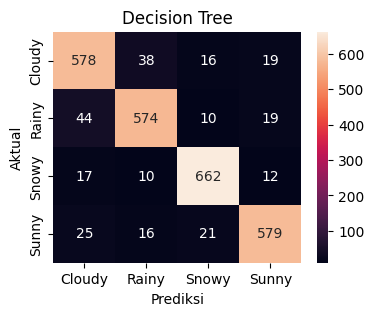

In [ ]:
fig, axes = plt.subplots(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test,y_pred_dt),annot=True,fmt='d', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
axes.set_title("Decision Tree")
axes.set_xlabel("Prediksi")
axes.set_ylabel("Aktual")

plt.show()

#####penjelasan kode:#####
### confusion_matrix(y_test,y_pred_dt): menghitung confusion matrix dari data aktual (y_test) dan hasil prediksi model (y_pred_dt)
#baris: label sebenarnya
#kolom: label prediksi

### fmt = 'd': agar nilai dalam integer

### xticklabels=np.unique(y_test): memberikan label pada sumbu x (label yg diprediksi) menggunakan nilai unik dalam y_test

### yticklabels=np.unique(y_test): memberikan label pada sumbu y (label yg sebenarnya) menggunakan nilai unik dalam y_test

### Cara baca
# Diagonal: jumlah prediksi benar (true positives atau true negative) untuk setiap label
# Nilai diluar diagonal: jumlah prediksi salah (false positives atau false negatives)

## Model Building With Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model = RandomForestClassifier(random_state=42)

In [ ]:
 rf_model.fit(x_train,y_train)

RandomForestClassifier(random_state=42)

In [ ]:
y_pred_rf = rf_model.predict(x_test)
rf_accuracy = accuracy_score(y_test,y_pred_rf)
rf_accuracy

0.9098484848484848

In [ ]:
print(classification_report(y_test,y_pred_rf, digits=4))

              precision    recall  f1-score   support

      Cloudy     0.8674    0.8940    0.8805       651
       Rainy     0.9112    0.9042    0.9077       647
       Snowy     0.9309    0.9415    0.9362       701
       Sunny     0.9304    0.8970    0.9134       641

    accuracy                         0.9098      2640
   macro avg     0.9100    0.9092    0.9094      2640
weighted avg     0.9103    0.9098    0.9099      2640



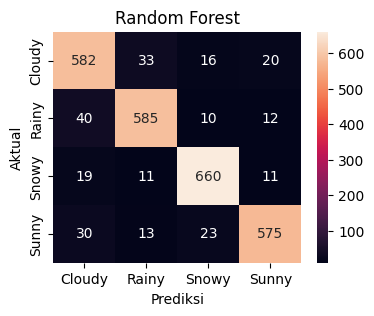

In [ ]:
fig, axes = plt.subplots(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test,y_pred_rf),annot=True,fmt='d', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
axes.set_title("Random Forest")
axes.set_xlabel("Prediksi")
axes.set_ylabel("Aktual")

plt.show()

# Optimizing Random Forest Using GSCV

In [ ]:
from sklearn.model_selection import GridSearchCV, train_test_split, cross_val_score
from sklearn.metrics import r2_score

In [ ]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10]
}

# GridSearchCV
grid_search = GridSearchCV(estimator=rf_model, param_grid=param_grid, scoring='accuracy', cv=3, verbose=1, n_jobs=-1)
grid_search.fit(x_train, y_train)

Fitting 3 folds for each of 27 candidates, totalling 81 fits


/usr/local/lib/python3.10/dist-packages/numpy/ma/core.py:2820: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [10, 20, 30],
                         'min_samples_split': [2, 5, 10],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy', verbose=1)

In [ ]:
# Evaluasi
best_model = grid_search.best_estimator_
cv_scores = cross_val_score(best_model, x_train, y_train, cv=3)  # 3 folds untuk validasi silang

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Cross-Validation Scores: {cv_scores}")
print(f"Average Cross-Validation Accuracy: {grid_search.best_score_}")

Best Parameters: {'max_depth': 30, 'min_samples_split': 10, 'n_estimators': 100}
Cross-Validation Scores: [0.91732955 0.91221591 0.92244318]
Average Cross-Validation Accuracy: 0.9173295454545455


In [ ]:
# Hasil GridSearchCV dalam DataFrame
results = pd.DataFrame(grid_search.cv_results_)

In [ ]:
results[['param_n_estimators', 'param_max_depth', 'param_min_samples_split', 'mean_test_score', 'rank_test_score']].sort_values(by='rank_test_score')

,param_n_estimators,param_max_depth,param_min_samples_split,mean_test_score,rank_test_score
25,100,30,10,0.917330,1
16,100,20,10,0.917140,2
22,100,30,5,0.916667,3
13,100,20,5,0.916477,4
17,200,20,10,0.916288,5
26,200,30,10,0.916193,6
2,200,10,2,0.916193,7
24,50,30,10,0.916098,8
11,200,20,2,0.916004,9
15,50,20,10,0.916004,9


In [ ]:
y_pred_rf_gscv = best_model.predict(x_test)
rf_gscv_accuracy = accuracy_score(y_test,y_pred_rf_gscv)
rf_gscv_accuracy

0.915530303030303

Membandingkan beberapa top parameter pada GSCV

In [ ]:
rf_GSCVmodel_2nd = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=20, min_samples_split=10)
rf_GSCVmodel_3rd = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=30, min_samples_split=5)
rf_GSCVmodel_4th = RandomForestClassifier(random_state=42, n_estimators=100, max_depth=20, min_samples_split=5)
rf_GSCVmodel_5th = RandomForestClassifier(random_state=42, n_estimators=200, max_depth=20, min_samples_split=10)

In [ ]:
rf_GSCVmodel_2nd.fit(x_train,y_train)
rf_GSCVmodel_3rd.fit(x_train,y_train)
rf_GSCVmodel_4th.fit(x_train,y_train)
rf_GSCVmodel_5th.fit(x_train,y_train)

RandomForestClassifier(max_depth=20, min_samples_split=10, n_estimators=200,
                       random_state=42)

In [ ]:
print('Akurasi GSCV 1 :', rf_gscv_accuracy)

y_pred_rf_gscv_2nd = rf_GSCVmodel_2nd.predict(x_test)
rf_gscv_2nd_accuracy = accuracy_score(y_test,y_pred_rf_gscv_2nd)
print('Akurasi GSCV 2 :', rf_gscv_2nd_accuracy)

y_pred_rf_gscv_3rd = rf_GSCVmodel_3rd.predict(x_test)
rf_gscv_3rd_accuracy = accuracy_score(y_test,y_pred_rf_gscv_3rd)
print('Akurasi GSCV 3 :', rf_gscv_3rd_accuracy)

y_pred_rf_gscv_4th = rf_GSCVmodel_4th.predict(x_test)
rf_gscv_4th_accuracy = accuracy_score(y_test,y_pred_rf_gscv_4th)
print('Akurasi GSCV 4 :', rf_gscv_4th_accuracy)

y_pred_rf_gscv_5th = rf_GSCVmodel_5th.predict(x_test)
rf_gscv_5th_accuracy = accuracy_score(y_test,y_pred_rf_gscv_5th)
print('Akurasi GSCV 5 :', rf_gscv_5th_accuracy)

Akurasi GSCV 1 : 0.915530303030303
Akurasi GSCV 2 : 0.9162878787878788
Akurasi GSCV 3 : 0.9117424242424242
Akurasi GSCV 4 : 0.9143939393939394
Akurasi GSCV 5 : 0.9143939393939394


In [ ]:
print(classification_report(y_test,y_pred_rf_gscv, digits=4))

              precision    recall  f1-score   support

      Cloudy     0.8729    0.8971    0.8848       651
       Rainy     0.9038    0.9150    0.9094       647
       Snowy     0.9365    0.9472    0.9418       701
       Sunny     0.9506    0.9002    0.9247       641

    accuracy                         0.9155      2640
   macro avg     0.9160    0.9149    0.9152      2640
weighted avg     0.9162    0.9155    0.9157      2640



In [ ]:
print(classification_report(y_test,y_pred_rf_gscv_2nd, digits=4))


              precision    recall  f1-score   support

      Cloudy     0.8757    0.8986    0.8870       651
       Rainy     0.9023    0.9134    0.9078       647
       Snowy     0.9352    0.9472    0.9412       701
       Sunny     0.9539    0.9033    0.9279       641

    accuracy                         0.9163      2640
   macro avg     0.9168    0.9156    0.9160      2640
weighted avg     0.9170    0.9163    0.9164      2640



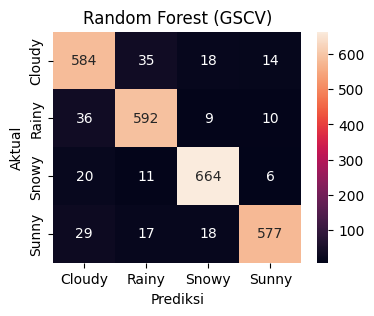

In [ ]:
fig, axes = plt.subplots(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test,y_pred_rf_gscv),annot=True,fmt='d', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
axes.set_title("Random Forest (GSCV)")
axes.set_xlabel("Prediksi")
axes.set_ylabel("Aktual")

plt.show()

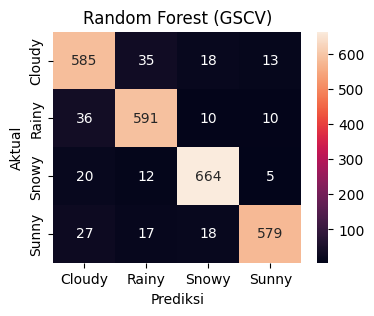

In [ ]:
fig, axes = plt.subplots(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test,y_pred_rf_gscv_2nd),annot=True,fmt='d', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
axes.set_title("Random Forest (GSCV)")
axes.set_xlabel("Prediksi")
axes.set_ylabel("Aktual")

plt.show()

# Perbandingan HeatMap

In [ ]:
print("Decision Tree Accuracy:", dt_accuracy)
print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest (GSCV) Accuracy:", rf_gscv_2nd_accuracy)

Decision Tree Accuracy: 0.906439393939394
Random Forest Accuracy: 0.9098484848484848
Random Forest (GSCV) Accuracy: 0.9162878787878788


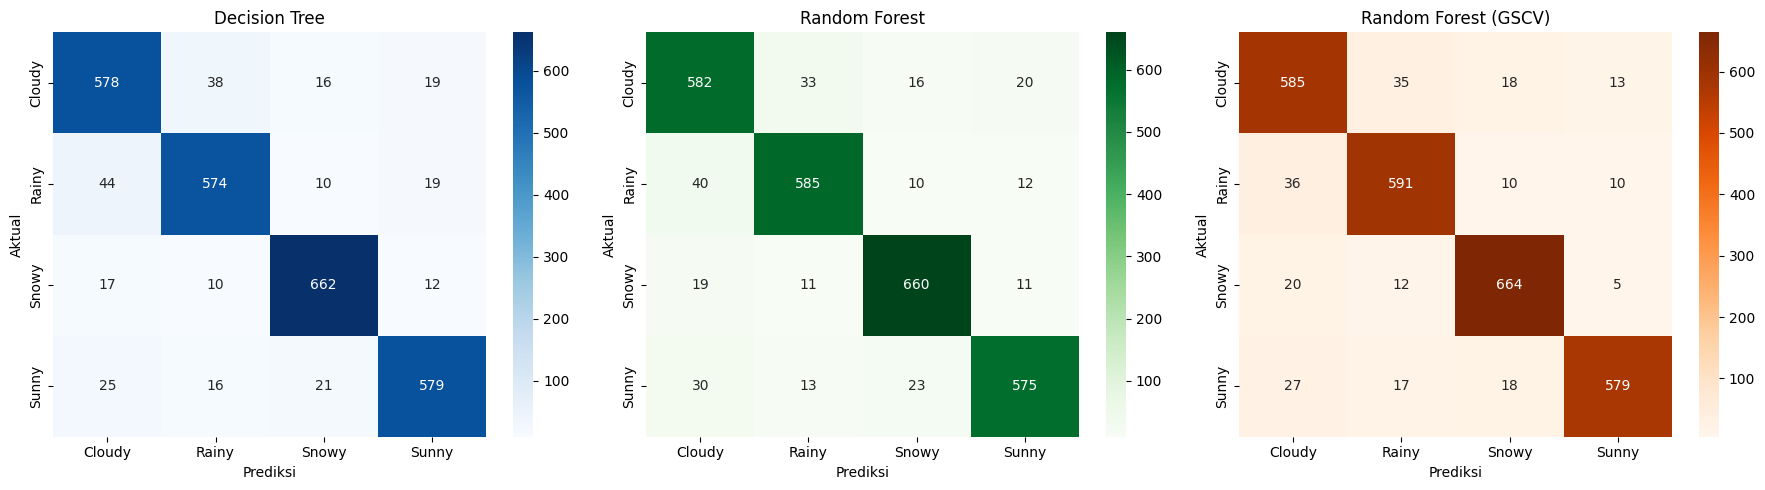

In [ ]:
# Membuat figure
fig, axes = plt.subplots(1, 3, figsize=(18, 5))  # 1 baris, 3 kolom

# Decision Tree
cm_dt = confusion_matrix(y_test, y_pred_dt)
sns.heatmap(cm_dt, annot=True, fmt='d', ax=axes[0], cmap='Blues', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
axes[0].set_title("Decision Tree")
axes[0].set_xlabel("Prediksi")
axes[0].set_ylabel("Aktual")

# Random Forest
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', ax=axes[1], cmap='Greens', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
axes[1].set_title("Random Forest")
axes[1].set_xlabel("Prediksi")
axes[1].set_ylabel("Aktual")

# Random Forest with Grid Search
cm_rf_gscv = confusion_matrix(y_test, y_pred_rf_gscv_2nd)
sns.heatmap(cm_rf_gscv, annot=True, fmt='d', ax=axes[2], cmap='Oranges', xticklabels=np.unique(y_test), yticklabels=np.unique(y_test))
axes[2].set_title("Random Forest (GSCV)")
axes[2].set_xlabel("Prediksi")
axes[2].set_ylabel("Aktual")

# Menampilkan plot
plt.tight_layout()
plt.show()